# Retrieval Strategy Benchmark
Comparing BM25 vs Dense vs Hybrid on ingested papers.

In [1]:
import asyncio
import sys
import nest_asyncio
nest_asyncio.apply()

sys.path.insert(0, '..')
from dotenv import load_dotenv
load_dotenv('../.env')
from src.embeddings.embedder import embed_single
from src.storage.elasticsearch_store import bm25_search
from src.storage.pgvector_store import dense_search
from src.retrieval.hybrid import hybrid_search

/Users/marcresaenrich/Desktop/rag-support-system/.venv/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
TEST_QUERIES = [
    'how does attention mechanism work',
    'transformer architecture encoder decoder',
    'large language model training',
    'sequence to sequence models',
    'neural network self attention',
]

In [3]:
async def run_all_strategies(query, k=3):
    embedding = embed_single(query)
    bm25 = await bm25_search(query, k=k)
    dense = await dense_search(embedding, k=k)
    hybrid = await hybrid_search(query, k=k)
    return {'bm25': bm25, 'dense': dense, 'hybrid': hybrid}

results = {}
for query in TEST_QUERIES:
    results[query] = await run_all_strategies(query)
    print(f'Done: {query}')

Done: how does attention mechanism work
Done: transformer architecture encoder decoder
Done: large language model training
Done: sequence to sequence models
Done: neural network self attention


In [4]:
print(f"{'Query':<45} {'BM25 top1':<30} {'Dense top1':<30} {'Hybrid top1':<30}")
print('-' * 135)
for query, res in results.items():
    bm25_top  = res['bm25'][0]['content'][:28]  if res['bm25']  else 'NO RESULT'
    dense_top = res['dense'][0]['content'][:28] if res['dense'] else 'NO RESULT'
    hyb_top   = res['hybrid'][0]['content'][:28] if res['hybrid'] else 'NO RESULT'
    print(f'{query:<45} {bm25_top:<30} {dense_top:<30} {hyb_top:<30}')

Query                                         BM25 top1                      Dense top1                     Hybrid top1                   
---------------------------------------------------------------------------------------------------------------------------------------
how does attention mechanism work             performing models also conne   Attention Is All You Need Th   performing models also conne  
transformer architecture encoder decoder      performing models also conne   performing models also conne   performing models also conne  
large language model training                 Transformer generalizes well   Attention Is All You Need Th   Transformer generalizes well  
sequence to sequence models                   Attention Is All You Need Th   Attention Is All You Need Th   Attention Is All You Need Th  
neural network self attention                 Attention Is All You Need Th   performing models also conne   Attention Is All You Need Th  


Matplotlib is building the font cache; this may take a moment.


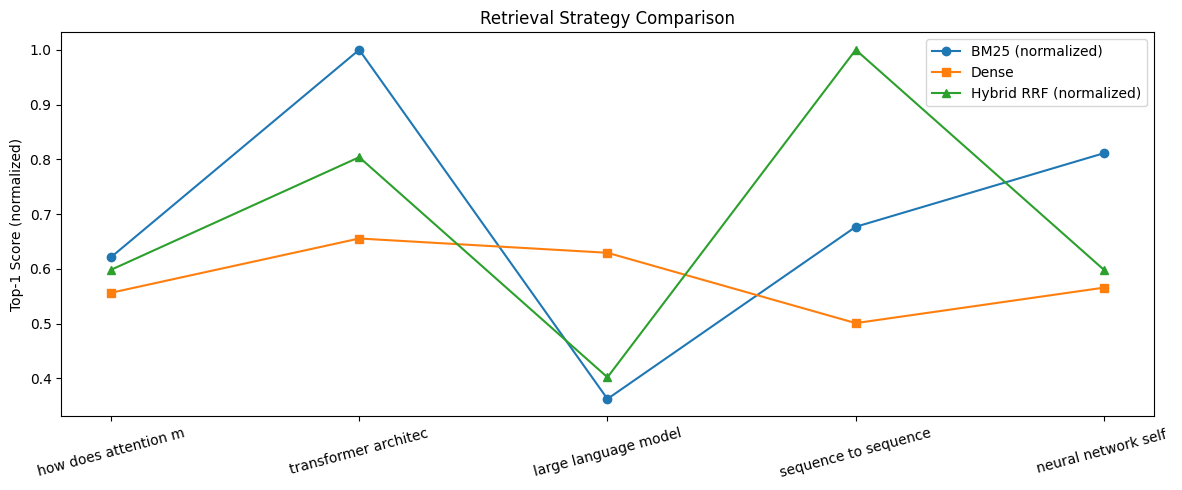

Chart saved to notebooks/retrieval_benchmark.png


In [5]:
import matplotlib.pyplot as plt

bm25_scores   = [results[q]['bm25'][0]['score']   if results[q]['bm25']   else 0 for q in TEST_QUERIES]
dense_scores  = [results[q]['dense'][0]['score']  if results[q]['dense']  else 0 for q in TEST_QUERIES]
hybrid_scores = [results[q]['hybrid'][0]['score'] if results[q]['hybrid'] else 0 for q in TEST_QUERIES]

x = range(len(TEST_QUERIES))
short_queries = [q[:20] for q in TEST_QUERIES]

plt.figure(figsize=(12, 5))
plt.plot(x, [s/max(bm25_scores) for s in bm25_scores],    marker='o', label='BM25 (normalized)')
plt.plot(x, dense_scores,                                   marker='s', label='Dense')
plt.plot(x, [s/max(hybrid_scores) for s in hybrid_scores], marker='^', label='Hybrid RRF (normalized)')
plt.xticks(x, short_queries, rotation=15)
plt.ylabel('Top-1 Score (normalized)')
plt.title('Retrieval Strategy Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('retrieval_benchmark.png')
plt.show()
print('Chart saved to notebooks/retrieval_benchmark.png')